<a href="https://colab.research.google.com/github/joaofelizardooo/analisando_dados_airbnb_austin_texas/blob/main/Analisando_os_Dados_do_Airbnb_(Austin).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise dos Dados do Airbnb - *Austin*

<center><img alt="Austin" width="50%" src="https://assets.simpleviewinc.com/simpleview/image/upload/c_fill,f_avif,g_xy_center,h_384,q_65,w_575,x_1328,y_571/v1/clients/austin/Downtown_Skyline_Upscale_Paulina_Skarbowska_Wiewior_bateyes_atx_Lifetime_Usage__4469f6fe-40d5-4df8-8fee-22b3b75c9862.jpg"></center>

O [Airbnb](https://www.airbnb.com.br/) já é considerado como sendo a **maior empresa hoteleira da atualidade**. Ah, o detalhe é que ele **não possui nenhum hotel**!

Conectando pessoas que querem viajar (e se hospedar) com anfitriões que querem alugar seus imóveis de maneira prática, o Airbnb fornece uma plataforma inovadora para tornar essa hospedagem alternativa.

No final de 2018, a Startup fundada 10 anos atrás, já havia **hospedado mais de 300 milhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais.

Uma das iniciativas do Airbnb é disponibilizar dados do site, para algumas das principais cidades do mundo. Por meio do portal [Inside Airbnb](http://insideairbnb.com/get-the-data.html), é possível baixar uma grande quantidade de dados para desenvolver projetos e soluções de *Data Science*.

<center><img alt="Analisando Airbnb" width="30%" src="https://cdn.worldvectorlogo.com/logos/airbnb-logo-belo-1.svg"></center>

**Neste *notebook*, iremos analisar os dados referentes à cidade Austin, e ver quais insights podem ser extraídos a partir de dados brutos.**

## Obtenção dos Dados


In [2]:
# importar os pacotes necessarios
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importar o arquivo listings.csv para um DataFrame
df = pd.read_csv('https://data.insideairbnb.com/united-states/tx/austin/2025-09-16/visualisations/listings.csv')

## Análise dos Dados


**Dicionário das variáveis**
* `id` - Número de id gerado para identificar o imóvel
* `name` - Nome da propriedade anunciada
* `host_id` - Número de id do proprietário(anfitrião) da propiedade
* `host_name` - Nome do anfitrião
* `neighbourhood_group` - Coluna inteira de valores ausentes (NaN)
* `neighbourhood` - Código postal de cada vizinhança
* `latitude` - Latitude da propriedade
* `longitude` - Longitude da propriedade
* `room_type` - Tipo de quarto oferecido
* `price` - Preço dos quartos em dolar
* `minimum_nights` - Quantidade minima de noites para reservar
* `number_of_reviews` - Número de avaliações que a propriedade tem
* `last_review` - Data da ultima avaliação
* `reviews_per_month` - Quantidade de avaliações por mês
* `calculated_host_listings_count` - Número de imóveis de um mesmo anfitrião
* `availability_365` - Número de dias de disponibilidade dentro de 365 dias
* `number_of_reviews_ltm` - Número de avaliações no ultimo 1 ano (12 meses)
* `license` - Coluna inteira de valores ausentes (NaN)

Antes de iniciar qualquer análise, vamos verificar a cara do nosso *dataset*, analisando as 5 primeiras entradas.

In [4]:
# mostrar as 5 primeiras entradas
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,5456,"Walk to 6th, Rainey St and Convention Ctr",8028,Sylvia,NaN,78702,30.26057,-97.73441,Entire home/apt,97.0,2,708,2025-09-02,3.52,1,328,25,NaN
1,6448,"Secluded Studio @ Zilker - King Bed, Bright & ...",14156,Amy,NaN,78704,30.26034,-97.76487,Entire home/apt,160.0,3,339,2025-08-20,1.98,1,316,14,NaN
2,8502,Woodland Studio Lodging,25298,Karen,NaN,78741,30.23466,-97.73682,Entire home/apt,38.0,4,54,2025-05-05,0.28,1,88,1,NaN
3,13035,Historic house in highly walkable East Austin,50793,Margaret Ann,NaN,78702,30.26098,-97.73072,Entire home/apt,145.0,15,19,2025-07-31,0.11,2,321,1,NaN
4,22828,Garage Apartment central SE Austin,56488,David,NaN,78741,30.23614,-97.73225,Entire home/apt,58.0,30,56,2025-08-16,0.30,1,211,3,NaN


### **Q1. Quantos atributos (variáveis) e quantas entradas o nosso conjunto de dados possui? Quais os tipos das variáveis?**

In [5]:
# identificar o volume de dados do DataFrame
print(f'Observações: {df.shape[0]}')
print(f'Variáveis: {df.shape[1]}')

# verificar as 5 primeiras entradas do dataset
print(f'\nTipos de variáveis\n{df.dtypes}')

Observações: 10533
Variáveis: 18

Tipos de variáveis
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                       int64
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                           float64
dtype: object


### **Q2. Qual a porcentagem de valores ausentes no *dataset*?**

In [6]:
# ordenar em ordem decrescente as variáveis por seus valores ausentes
pvalores_ausentes = (df.isnull().sum()/df.shape[0]*100).sort_values(ascending=False)
print(f'Porcentagem de valores ausentes\n{pvalores_ausentes}')

Porcentagem de valores ausentes
license                           100.000000
neighbourhood_group               100.000000
reviews_per_month                  15.418209
last_review                        15.418209
price                               0.151904
host_name                           0.085446
name                                0.000000
id                                  0.000000
neighbourhood                       0.000000
host_id                             0.000000
room_type                           0.000000
longitude                           0.000000
latitude                            0.000000
number_of_reviews                   0.000000
minimum_nights                      0.000000
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
dtype: float64


### **Q3. Qual o tipo de distribuição das variáveis?**

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'neighbourhood_group'}>,
        <Axes: title={'center': 'neighbourhood'}>],
       [<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>],
       [<Axes: title={'center': 'number_of_reviews_ltm'}>,
        <Axes: title={'center': 'license'}>, <Axes: >, <Axes: >]],
      dtype=object)

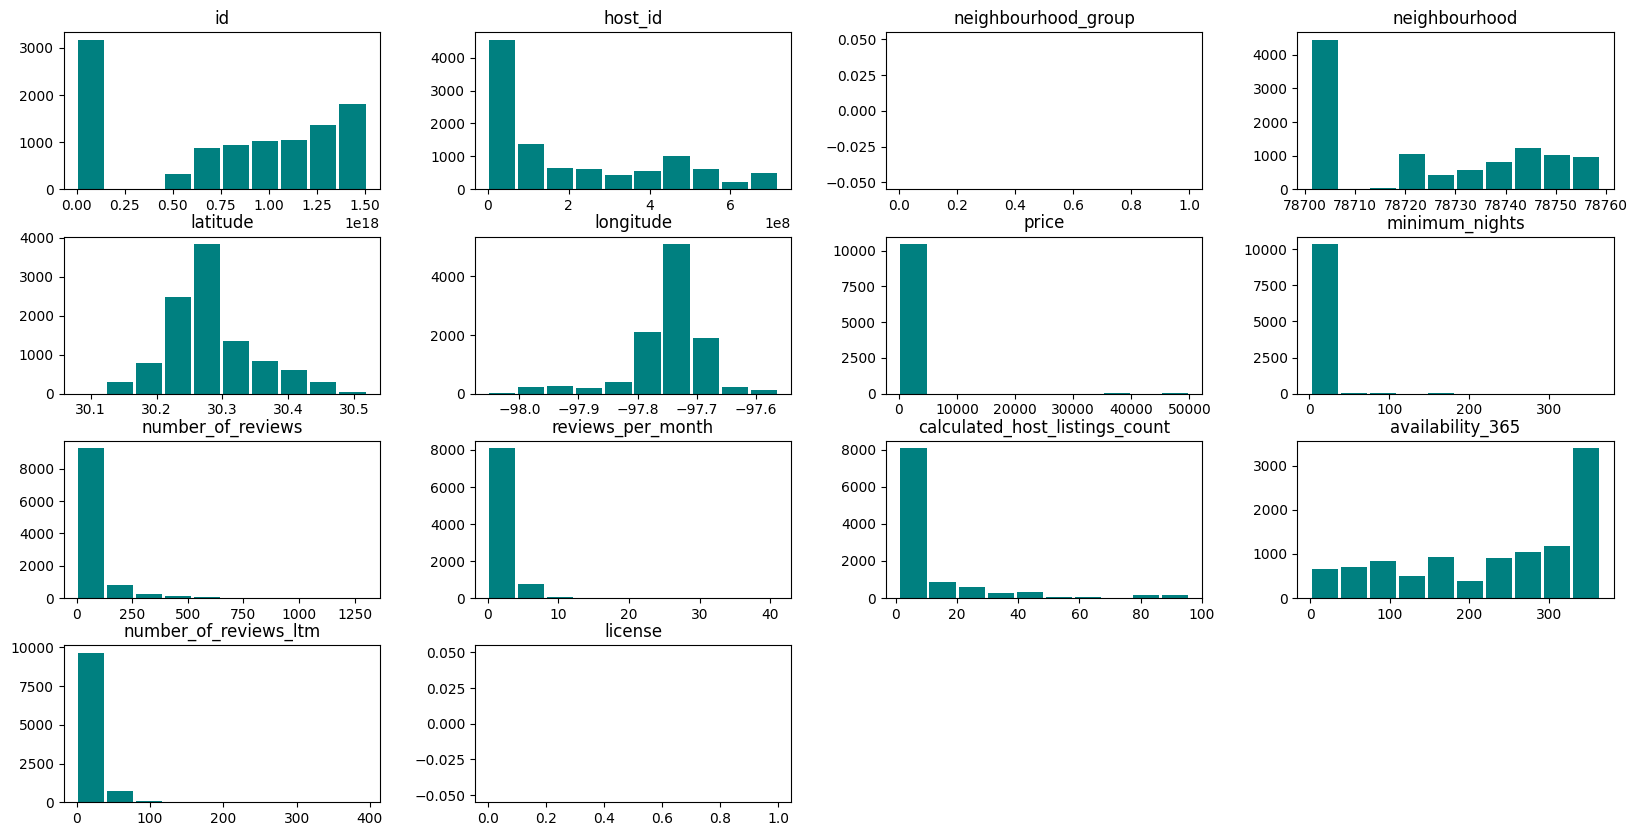

In [7]:
# plotar o histograma das variáveis numéricas
df.hist(figsize=(20,10),grid=False,color='#008080',rwidth=0.9)

### **Q4. Há *outliers* presentes?**
Pela distribuição do histograma, é possível verificar a presença de *outliers*. Olhe por exemplo as variáveis `price`, `minimum_nights` ,`number_of_reviews` e `number_of_reviews_ltm`.

Esses valores distorcem a apresentação dos histogramas e tambem impossibilitam a caracterização de seguirem uma distribuição.

* Vamos realizar um resumo estatístico com `.describe()`
* E plotar os boxplots para facilitar a visualização dos *outliers*.

In [8]:
df[['price', 'minimum_nights', 'number_of_reviews','number_of_reviews_ltm', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365']].describe()

,price,minimum_nights,number_of_reviews,number_of_reviews_ltm,reviews_per_month,calculated_host_listings_count,availability_365
count,10517.000000,10533.000000,10533.000000,10533.000000,8909.000000,10533.000000,10533.000000
mean,414.537701,7.768157,55.858920,13.065698,1.742838,9.856736,234.909238
std,2896.807897,20.586238,104.276866,18.844388,1.809563,17.808890,114.102467
min,8.000000,1.000000,0.000000,0.000000,0.010000,1.000000,0.000000
25%,86.000000,1.000000,2.000000,1.000000,0.430000,1.000000,143.000000
50%,135.000000,2.000000,17.000000,5.000000,1.230000,2.000000,263.000000
75%,226.000000,3.000000,62.000000,19.000000,2.510000,9.000000,339.000000
max,50000.000000,365.000000,1305.000000,396.000000,41.140000,96.000000,365.000000


Podemos ver que a variável `price` tem 75% dos seus valores até 226, sendo seu valor máximo 50.000. Outra variável que também chama a atenção é a `number_of_reviews`, que mostra que 75% dos imóveis receberam até 62 avaliações, mas há imóveis que receberam 1.305, sendo estes os mais populares.

####Boxplot para a variável number_of_reviews

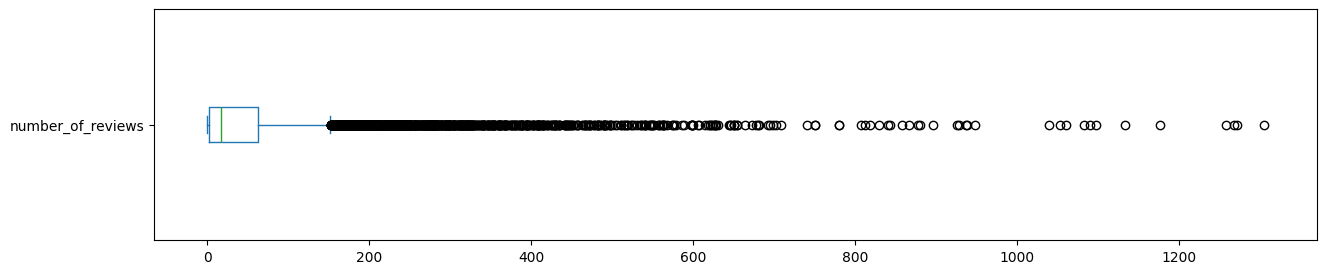


number_of_reviews: 
Numero de entradas acima de 150: 1070
10.1585%


In [9]:
df.number_of_reviews.plot(kind='box', figsize=(15,3), vert=False)
plt.show()

outliers1 = len(df.number_of_reviews[df.number_of_reviews > 150])
print(f'\nnumber_of_reviews: \nNumero de entradas acima de 150: {outliers1}')
print(f'{outliers1/df.shape[0]:.4%}')

####Boxplot para a variável price

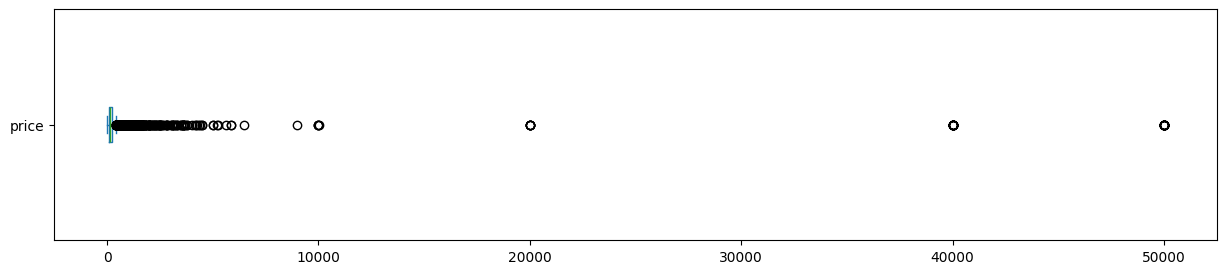


price: 
Numero de entradas acima de 226: 2625
24.9217%


In [10]:
df.price.plot(kind='box', figsize=(15,3), vert=False)
plt.show()

outliers2 = len(df.price[df.price > 226])
print(f'\nprice: \nNumero de entradas acima de 226: {outliers2}')
print(f'{outliers2/df.shape[0]:.4%}')

In [11]:
df.loc[df.price == 50000]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
5044,854345272833930897,"Best Value, Quality Stay! Pool, Pets Allowed!",501999514,RoomPicks,NaN,78701,30.26905,-97.74199,Hotel room,50000.0,1,1,2024-06-16,0.07,20,350,0,NaN
5092,864638323922330066,Explore Austin Texas! Enjoy Free Breakfast & P...,501999514,RoomPicks,NaN,78759,30.39327,-97.73909,Hotel room,50000.0,1,2,2025-08-31,0.07,20,340,1,NaN
5382,914467758332610526,"Prime Location! 2 Modern Units, Pet-friendly",501999514,RoomPicks,NaN,78701,30.26905,-97.74199,Hotel room,50000.0,1,0,NaN,NaN,20,350,0,NaN
5494,929639747887634076,"Comfortable Stay in Austin! Pet-Friendly, w/ P...",501999514,RoomPicks,NaN,78759,30.39327,-97.73909,Hotel room,50000.0,1,2,2024-09-01,0.10,20,323,0,NaN
5497,929647511839545360,"Relax and Unwind! w/ Pool, Near Northside Lawn!",501999514,RoomPicks,NaN,78759,30.39327,-97.73909,Hotel room,50000.0,1,20,2025-08-10,0.77,20,358,8,NaN
10467,1506489703141784961,Relaxing Suite | Pet-Friendly | Onsite Restaurant,701076945,Aishat,NaN,78723,30.29786,-97.70410,Hotel room,50000.0,1,0,NaN,NaN,19,187,0,NaN
10468,1506489717048142380,Origin Austin l Bull Suite l Stylish Texas Stay,701076945,Aishat,NaN,78723,30.29786,-97.70410,Hotel room,50000.0,1,0,NaN,NaN,19,235,0,NaN
10469,1506489726838208260,Modern Stay | Pet-Friendly | Fitness Center,701076945,Aishat,NaN,78723,30.29786,-97.70410,Hotel room,50000.0,1,0,NaN,NaN,19,235,0,NaN
10472,1506489770381093087,Relax & Dine | Near Downtown | Pet-Friendly Stay,701076945,Aishat,NaN,78723,30.29786,-97.70410,Hotel room,50000.0,1,0,NaN,NaN,19,303,0,NaN
10473,1506489777265848434,Double Queen Deluxe l Origin Austin l Spacious,701076945,Aishat,NaN,78723,30.29786,-97.70410,Hotel room,50000.0,1,0,NaN,NaN,19,303,0,NaN


Nota-se que as propriedades com valor de 50.000 estão concentradas em apenas dois proprietários: RoomPicks e Aishat. Ambos os registros referem-se a quartos de hotel, o que sugere que sejam estabelecimentos de luxo localizados na cidade.

### Tratando valores ausentes(NaN) e outliers

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'neighbourhood'}>],
       [<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'number_of_reviews_ltm'}>]], dtype=object)

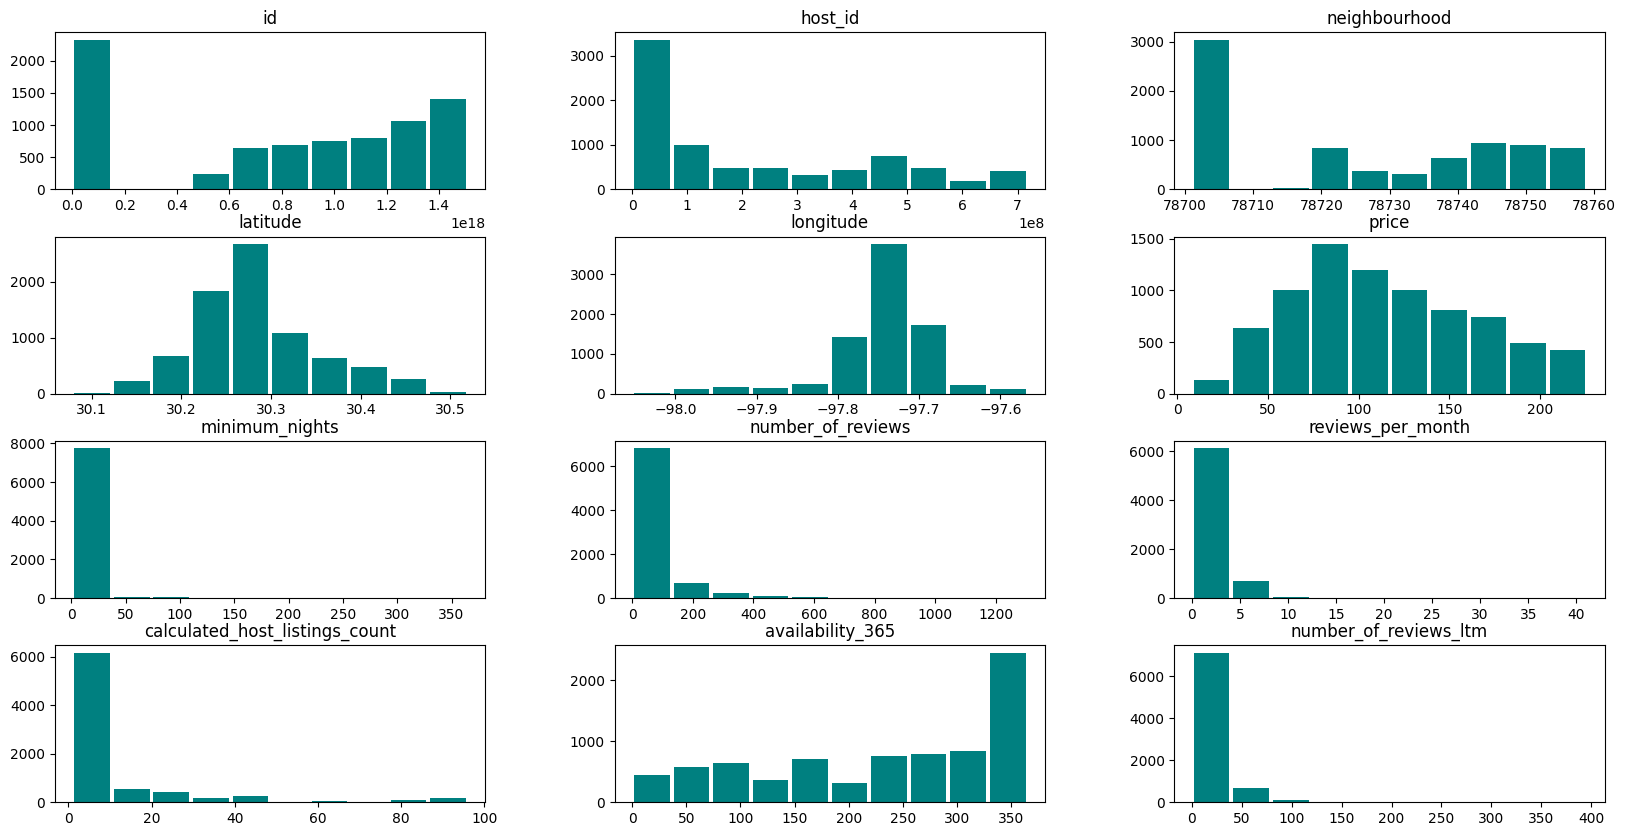

In [12]:
df_clean = df.copy()

# Removendo duas colunas que são compostas inteiramente por NaN
df_clean.drop('license',axis=1,inplace=True)
df_clean.drop('neighbourhood_group',axis=1,inplace=True)

# Removendo outliers da variável price
df_clean.drop(df_clean[df_clean.price > 226].index,inplace=True)

# Histograma sem os outliers da variável price e sem as duas colunas de NaN
df_clean.hist(figsize=(20,10),grid=False,color='#008080',rwidth=0.9)



### **Q5. Qual a correlação existente entre as variáveis**

In [13]:
# criar uma matriz de correlação
m_corr = df_clean[['price','minimum_nights','number_of_reviews','number_of_reviews_ltm','reviews_per_month','availability_365','calculated_host_listings_count']].corr()
# mostrar a matriz de correlação
display(m_corr)


,price,minimum_nights,number_of_reviews,number_of_reviews_ltm,reviews_per_month,availability_365,calculated_host_listings_count
price,1.000000,-0.066897,-0.006463,0.011303,-0.000845,0.015219,-0.055555
minimum_nights,-0.066897,1.000000,-0.133562,-0.210013,-0.244315,0.077660,0.029215
number_of_reviews,-0.006463,-0.133562,1.000000,0.611306,0.597228,-0.040853,-0.095309
number_of_reviews_ltm,0.011303,-0.210013,0.611306,1.000000,0.868668,-0.017546,-0.062195
reviews_per_month,-0.000845,-0.244315,0.597228,0.868668,1.000000,0.029435,-0.060934
availability_365,0.015219,0.077660,-0.040853,-0.017546,0.029435,1.000000,0.210282
calculated_host_listings_count,-0.055555,0.029215,-0.095309,-0.062195,-0.060934,0.210282,1.000000


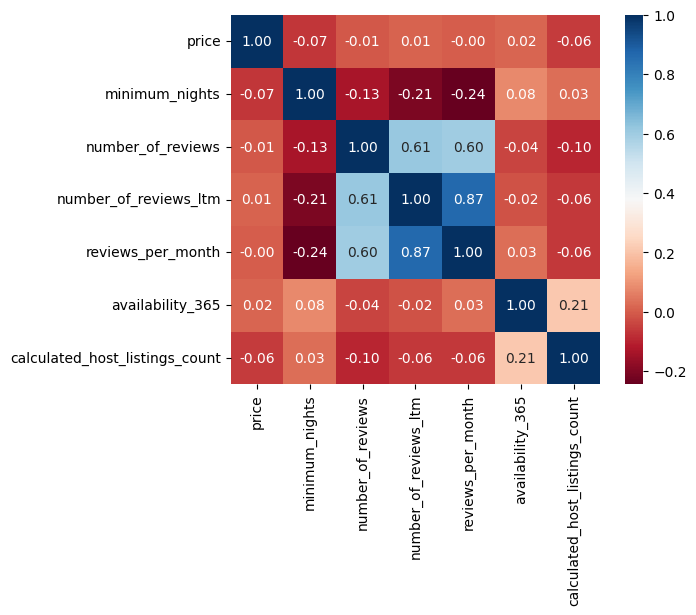

In [14]:
# plotar um heatmap a partir das correlações
sns.heatmap(m_corr, cmap='RdBu', fmt='.2f', square=True, linecolor='white', annot=True);

### **Q6. Qual o tipo de imóvel mais alugado no Airbnb?**

In [15]:
# mostrar a quantidade de cada tipo de imóvel disponível
df_clean.room_type.value_counts()

,count
room_type,
Entire home/apt,6629
Private room,1202
Shared room,65
Hotel room,12


In [16]:
# mostrar a porcentagem de cada tipo de imóvel disponível
df_clean.room_type.value_counts() / df_clean.shape[0]

,count
room_type,
Entire home/apt,0.838265
Private room,0.151998
Shared room,0.008220
Hotel room,0.001517


A grande maioria das ofertas (83,8%) concentra-se em casas ou apartamentos inteiros; em contrapartida, a presença de quartos de hotel na plataforma é mínima dentro da cidade.

### **Q7. Qual a localidade mais cara do dataset?**



In [20]:
# ver preços por bairros, na média
df_clean.groupby('neighbourhood').price.mean().sort_values(ascending=False)[:10]

,price
neighbourhood,
78701,158.157588
78732,148.880000
78734,140.407895
78738,139.200000
78703,130.320000
78736,127.645161
78737,127.556818
78733,127.000000
78702,123.723977


In [36]:
imoveis_centro = df_clean[df_clean.neighbourhood == 78701].shape[0]
imoveis_Steiner_Ranch = df_clean[df_clean.neighbourhood == 78732].shape[0]
print(f'Imóveis do Centro: {imoveis_centro}')
print(f'Imóveis do Steiner Ranch: {imoveis_Steiner_Ranch}')

Imóveis do Centro: 517
Imóveis do Steiner Ranch: 25


Ao analisarmos os códigos postais, observa-se que a região com a maior média de preços é o Centro (78701). Na sequência, destaca-se Steiner Ranch (78732), uma comunidade planejada de luxo localizada no noroeste de Austin. Percebemos que o Centro possui um volume muito maior de imóveis e, ainda assim, mantém uma média elevada. Já a segunda região mencionada conta com apenas 25 imóveis; por ser uma amostra pequena, o preço médio não é tão robusto quanto o do Centro. Isso nos indica que a afirmação de que o Centro é uma região cara , além de intuitiva, é estatisticamente muito mais sólida.

Site para identificar a região pelo código postal:
* https://insideairbnb.com/austin/

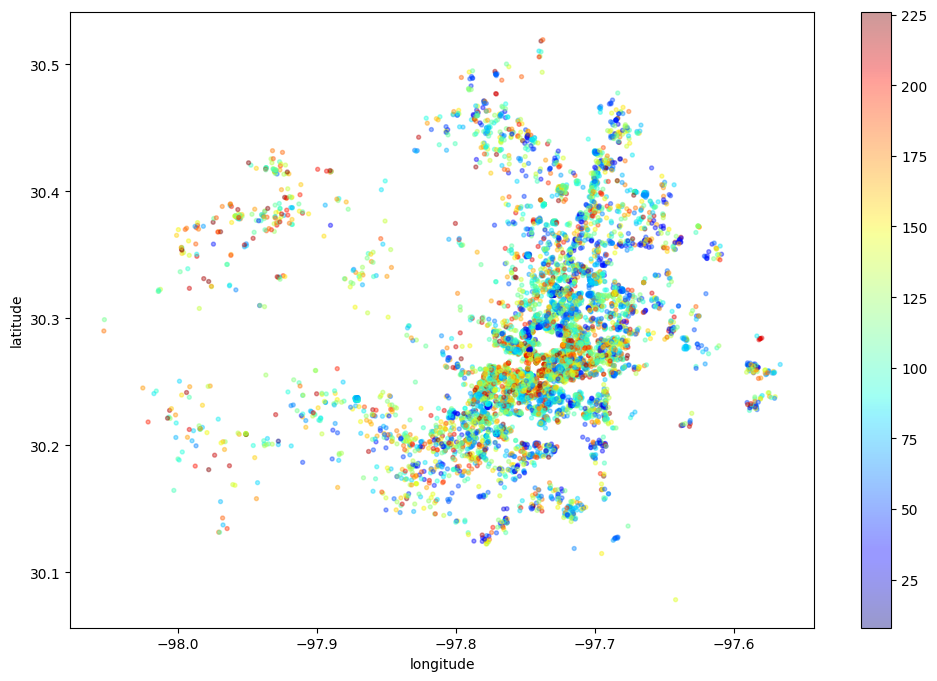

In [37]:
# plotar os imóveis pela latitude-longitude
df_clean.plot(kind="scatter", x='longitude', y='latitude', alpha=0.4, c=df_clean['price'], s=8,
              cmap=plt.get_cmap('jet'), figsize=(12,8));


Visualmente, nota-se uma maior densidade de imóveis e, consequentemente, de preços na região central da cidade, o que confirma a concentração de valores no núcleo urbano de Austin

### **Q8. Qual é a média do mínimo de noites para aluguel (minimum_nights)?**

In [33]:
# ver a média da coluna ``minimum_nights``
print(df_clean.minimum_nights.mean())

8.90048052604957


## Conclusões


Após uma análise exploratória detalhada dos dados do Airbnb para a cidade de Austin, podemos extrair conclusões significativas sobre o comportamento do mercado de aluguéis de curta temporada na região:

* Perfil do Inventário: O mercado de Austin é massivamente dominado por casas ou apartamentos inteiros (83,8%). Isso indica que a plataforma é utilizada principalmente para locação de residências completas, em vez de quartos compartilhados. A presença de quartos de hotel é mínima, o que reforça o caráter residencial da oferta na cidade.

* Disparidade de Preços e Outliers: A variável `price` revelou uma grande amplitude estatística. Enquanto 75% dos imóveis possuem diárias de até 226 dólares, identificamos valores extremos de até 50.000 dólares. Através de uma investigação mais profunda, constatamos que esses valores máximos pertencem a proprietários específicos (como RoomPicks e Aishat) e referem-se a quartos de hotel de luxo, fugindo do padrão do mercado imobiliário comum.

* Geografia do Valor: A análise por código postal confirmou que a região mais cara, de forma consistente, é o Centro (78701). Embora outras áreas, como Steiner Ranch (78732), apresentem médias elevadas, o volume reduzido de imóveis (apenas 25) torna essa média mais suscetível a variações e menos representativa. Assim, a liderança do Centro é estatisticamente mais sólida, dado o alto volume de ofertas que sustentam seu preço médio elevado.

* Engajamento dos Usuários: Notamos que a maioria dos imóveis recebe até 62 avaliações. No entanto, há propriedades extremamente populares com mais de 1.300 reviews, o que pode ser um indicador de hospitalidade excepcional ou localizações privilegiadas que geram alta rotatividade.

Em suma, o dataset apresentou uma qualidade razoável, exigindo limpeza apenas em colunas totalmente ausentes (`neighbourhood_group` e `license`) e o tratamento de outliers para que a realidade média de Austin não fosse distorcida por estabelecimentos de luxo isolados. Esta análise serve como uma base robusta para quem deseja entender as tendências de hospedagem ou investir no mercado imobiliário da capital do Texas.

In [38]:
!python --version

Python 3.12.12
